  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   

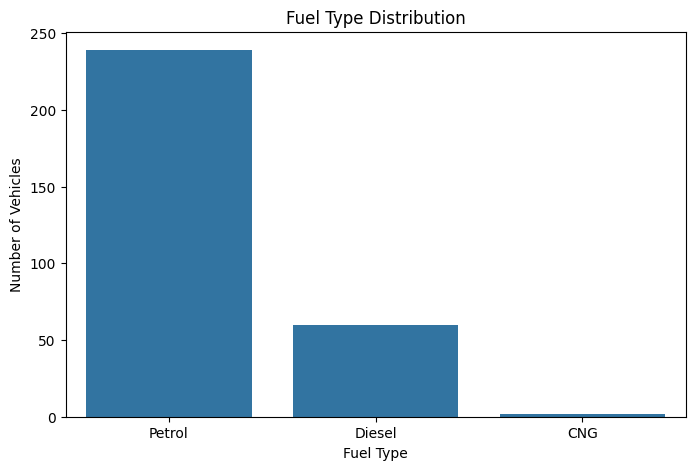

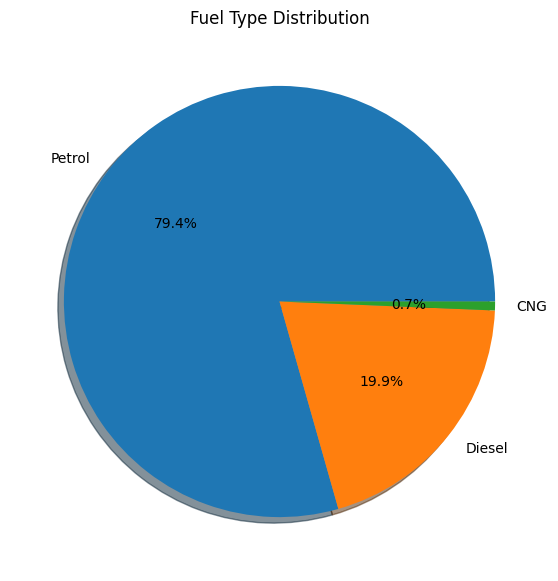


Seller Type Count:
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64


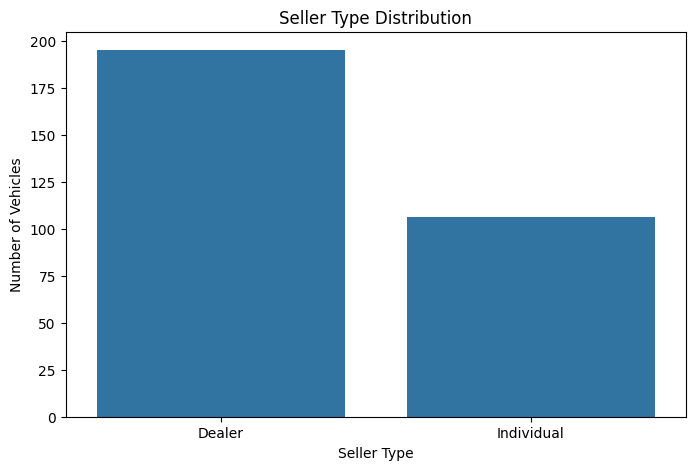


Transmission Count:
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


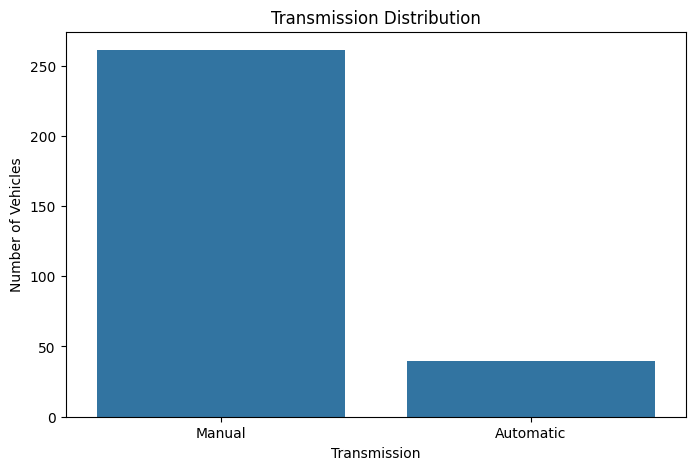


Owner Count:
Owner
0    290
1     10
3      1
Name: count, dtype: int64


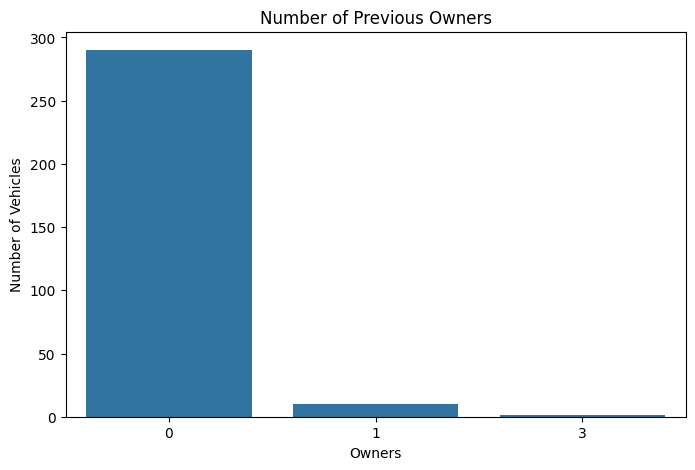

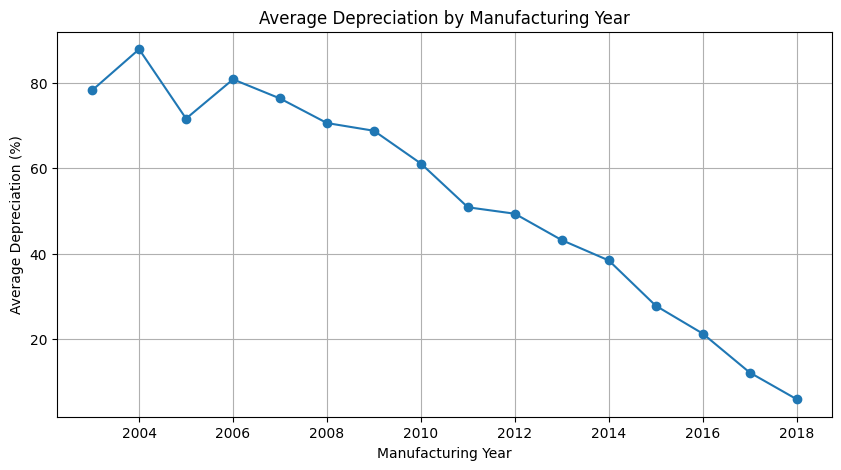

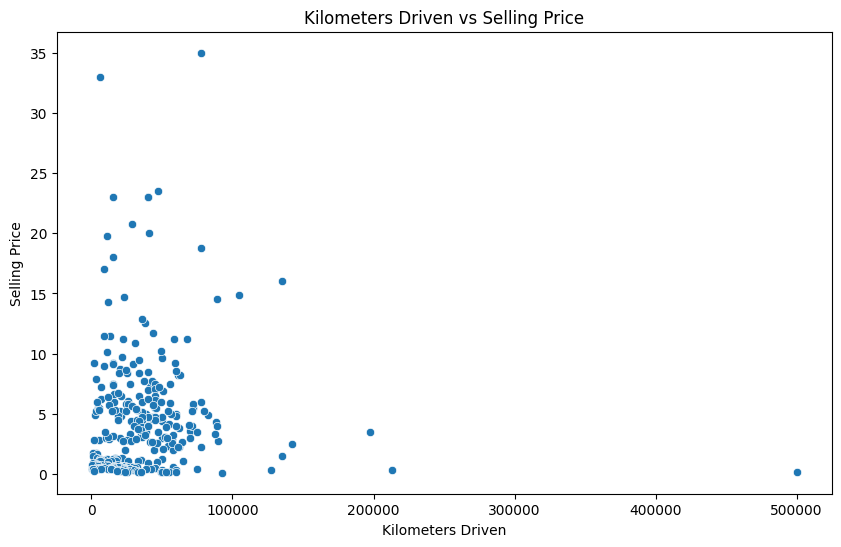

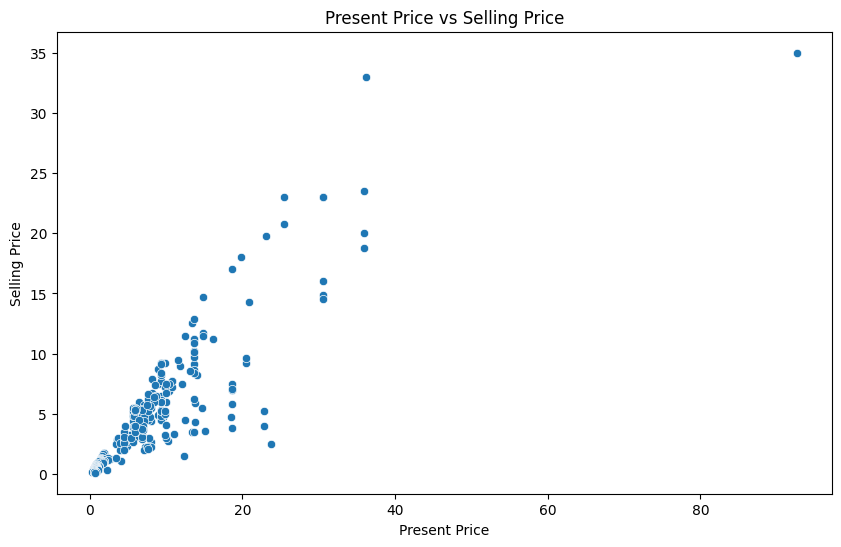

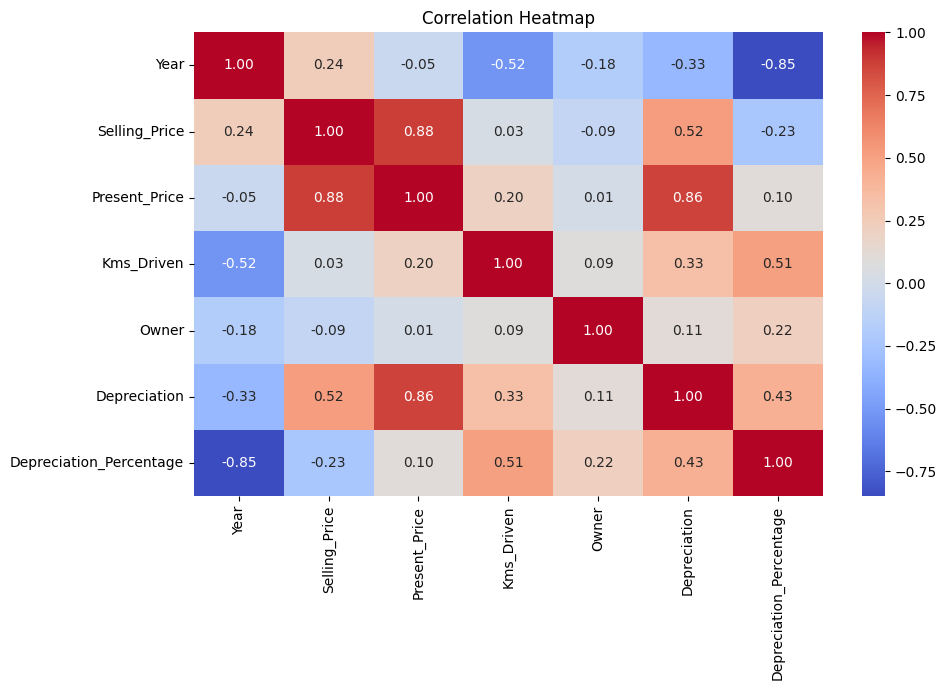


================ FINAL RESULTS ================
Manufacturing Years: 2003 - 2018
Lowest Selling Price: 0.1
Highest Selling Price: 35.0
Total Records: 301
Missing Values: 0
Different Vehicles: 98
Most Sold Vehicle: city
CNG Vehicles: 2
Individual Sellers: 106
Automatic Vehicles: 40
Single-owner Vehicles: 10


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv")

# Display first 5 rows
print(df.head())

# Display basic information
print("\nDataset Information:")
print(df.info())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# --------------------------------------------------
# 1. Manufacturing year range
# --------------------------------------------------
print("\n1. Manufacturing Year:")
print("Minimum Year:", df["Year"].min())
print("Maximum Year:", df["Year"].max())

# --------------------------------------------------
# 2. Lowest selling price
# --------------------------------------------------
print("\n2. Lowest Selling Price:")
print(df["Selling_Price"].min())

# --------------------------------------------------
# 3. Highest selling price
# --------------------------------------------------
print("\n3. Highest Selling Price:")
print(df["Selling_Price"].max())

# --------------------------------------------------
# 4. Total number of records
# --------------------------------------------------
print("\n4. Total Number of Records:")
print(len(df))

# --------------------------------------------------
# 5. Check missing values
# --------------------------------------------------
print("\n5. Missing Values:")
print(df.isnull().sum())

# --------------------------------------------------
# 6. Number of different vehicles
# --------------------------------------------------
print("\n6. Number of Different Vehicles:")
print(df["Car_Name"].nunique())

# --------------------------------------------------
# 7. Most sold vehicle
# --------------------------------------------------
print("\n7. Most Sold Vehicle:")
print(df["Car_Name"].value_counts().head(10))

print("Most Sold Vehicle:",
      df["Car_Name"].value_counts().idxmax())

# --------------------------------------------------
# 8. CNG vehicles
# --------------------------------------------------
print("\n8. CNG Vehicles:")
cng = df[df["Fuel_Type"] == "CNG"]
print("Number of CNG vehicles:", len(cng))
print(cng)

# --------------------------------------------------
# 9. Vehicles sold by individuals
# --------------------------------------------------
print("\n9. Vehicles Sold by Individuals:")
individual = df[df["Seller_Type"] == "Individual"]
print("Number of vehicles:", len(individual))

# --------------------------------------------------
# 10. Automatic transmission vehicles
# --------------------------------------------------
print("\n10. Automatic Transmission Vehicles:")
automatic = df[df["Transmission"] == "Automatic"]
print("Number of automatic vehicles:", len(automatic))

# --------------------------------------------------
# 11. Single-owner vehicles
# --------------------------------------------------
print("\n11. Single-owner Vehicles:")
single_owner = df[df["Owner"] == 1]
print("Number of single-owner vehicles:", len(single_owner))

# --------------------------------------------------
# 12. Cost depreciation
# --------------------------------------------------

# Calculate depreciation
df["Depreciation"] = df["Present_Price"] - df["Selling_Price"]

# Calculate depreciation percentage
df["Depreciation_Percentage"] = (
    df["Depreciation"] / df["Present_Price"]
) * 100

print("\n12. Most Depreciated Vehicle:")

most_depreciated = df.loc[
    df["Depreciation"].idxmax()
]

print(most_depreciated[
    [
        "Car_Name",
        "Present_Price",
        "Selling_Price",
        "Depreciation",
        "Depreciation_Percentage"
    ]
])

print("\nLeast Depreciated Vehicle:")

least_depreciated = df.loc[
    df["Depreciation"].idxmin()
]

print(least_depreciated[
    [
        "Car_Name",
        "Present_Price",
        "Selling_Price",
        "Depreciation",
        "Depreciation_Percentage"
    ]
])

# --------------------------------------------------
# 13. Vehicles less affected by depreciation
# --------------------------------------------------

print("\n13. Vehicles Less Affected by Depreciation:")

least_depreciated_cars = (
    df.groupby("Car_Name")["Depreciation_Percentage"]
    .mean()
    .sort_values()
)

print(least_depreciated_cars.head(10))

# --------------------------------------------------
# 14. Factors affecting depreciation
# --------------------------------------------------

print("\n14. Factors Affecting Depreciation:")

correlation = df[
    [
        "Year",
        "Selling_Price",
        "Present_Price",
        "Kms_Driven",
        "Owner",
        "Depreciation",
        "Depreciation_Percentage"
    ]
].corr()

print(correlation)

# --------------------------------------------------
# Fuel Type Analysis
# --------------------------------------------------

print("\nFuel Type Count:")
print(df["Fuel_Type"].value_counts())

# Bar chart
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Fuel_Type")
plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Vehicles")
plt.show()

# Pie chart
plt.figure(figsize=(7, 7))
df["Fuel_Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    shadow=True
)
plt.title("Fuel Type Distribution")
plt.ylabel("")
plt.show()

# --------------------------------------------------
# Seller Type Analysis
# --------------------------------------------------

print("\nSeller Type Count:")
print(df["Seller_Type"].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Seller_Type")
plt.title("Seller Type Distribution")
plt.xlabel("Seller Type")
plt.ylabel("Number of Vehicles")
plt.show()

# --------------------------------------------------
# Transmission Analysis
# --------------------------------------------------

print("\nTransmission Count:")
print(df["Transmission"].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Transmission")
plt.title("Transmission Distribution")
plt.xlabel("Transmission")
plt.ylabel("Number of Vehicles")
plt.show()

# --------------------------------------------------
# Owner Analysis
# --------------------------------------------------

print("\nOwner Count:")
print(df["Owner"].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Owner")
plt.title("Number of Previous Owners")
plt.xlabel("Owners")
plt.ylabel("Number of Vehicles")
plt.show()

# --------------------------------------------------
# Depreciation by Year
# --------------------------------------------------

year_depreciation = (
    df.groupby("Year")["Depreciation_Percentage"]
    .mean()
)

plt.figure(figsize=(10, 5))
year_depreciation.plot(marker="o")
plt.title("Average Depreciation by Manufacturing Year")
plt.xlabel("Manufacturing Year")
plt.ylabel("Average Depreciation (%)")
plt.grid()
plt.show()

# --------------------------------------------------
# Kilometers Driven vs Selling Price
# --------------------------------------------------

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Kms_Driven",
    y="Selling_Price"
)
plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.show()

# --------------------------------------------------
# Present Price vs Selling Price
# --------------------------------------------------

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price"
)
plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.show()

# --------------------------------------------------
# Correlation Heatmap
# --------------------------------------------------

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Final Results
# --------------------------------------------------

print("\n================ FINAL RESULTS ================")

print("Manufacturing Years:",
      df["Year"].min(), "-", df["Year"].max())

print("Lowest Selling Price:",
      df["Selling_Price"].min())

print("Highest Selling Price:",
      df["Selling_Price"].max())

print("Total Records:",
      len(df))

print("Missing Values:",
      df.isnull().sum().sum())

print("Different Vehicles:",
      df["Car_Name"].nunique())

print("Most Sold Vehicle:",
      df["Car_Name"].value_counts().idxmax())

print("CNG Vehicles:",
      (df["Fuel_Type"] == "CNG").sum())

print("Individual Sellers:",
      (df["Seller_Type"] == "Individual").sum())

print("Automatic Vehicles:",
      (df["Transmission"] == "Automatic").sum())

print("Single-owner Vehicles:",
      (df["Owner"] == 1).sum())

print("================================================")